<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo de Laboratorio Nº1
#### Grupo Nº1

### Consigna

<div align="center">

|  Grupo  |     Función de aproximación     | Frecuencia de corte | Frecuencia de stop | Atenuación máxima en banda de paso | Atenuación mínima en banda de stop |
|:------:|:-------------------------------:|:-------------------:|:------------------:|:----------------------------------:|:----------------------------------:|
|   1    |           Chebyshev             |      1.5 kHz        |      4.5 kHz       |              0.5 dB                |               16 dB                |

</div>

In [1]:
from IPython.display import HTML

file = "./TPL1_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from pytc2.sistemas_lineales import plot_plantilla, bodePlot

## Análisis de la Transferencia
Se Utilizan los valores de $Q$, $\omega_0$ y $k$ obtenidos para simular la transferencia obtenida con la plantilla.

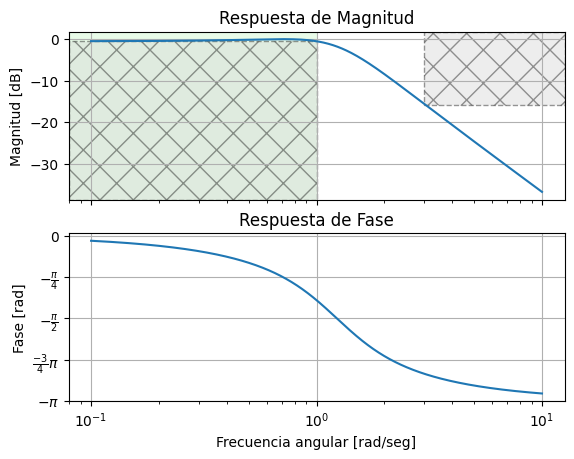

In [3]:
Q = 0.863
w0 = np.sqrt(1.5162)
k = 0.9438


num = np.array([k * w0**2])
den = np.array([1.0, w0 / Q, w0**2])

H = sig.TransferFunction(num, den)

fig_id, axes_hdl = bodePlot(
    H,
    xaxis="omega",
    fs=2 * np.pi,
)

plt.sca(axes_hdl[0])

plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)

# Síntesis

Se utiliza la transferencia de un Ackerberg-Mossberg

$$
H(s) = - \frac{R_3}{R_1} \;  \cfrac{\frac{1}{{R_3}^2 \, C^2}}{s^2 + s \, \frac{1}{R_2\, C} + \frac{1}{{R_3}^2 \, C^2}}
$$

Por lo tanto se tiene la siguiente expresión simplificada:

$$
H(s) = - k \;  \cfrac{{\omega_0}^2}{s^2 + s \, \frac{\omega_0}{Q} + {\omega_0}^2}
$$

Siendo los parámetros característicos del filtro:

$$k = \frac{R_3}{R_1}$$

$$\omega_0 =  \frac{1}{R_3 \, C}$$

$$Q =  \frac{R_2}{R_3}$$

In [4]:
R1, R2, R3, C = sp.symbols("R_1 R_2 R_3 C", real=True, positive=True)
w0, Q, k = sp.symbols("\omega_0 Q k", real=True, positive=True)
s = sp.symbols("s")

# Defino la transferencia T(s)
num = w0**2
den = s**2 + s * w0 / Q + w0**2
T = k * (num / den)

T

\omega_0**2*k/(\omega_0**2 + s**2 + \omega_0*s/Q)

## Normalización

$$\Omega_{\omega_0} = \omega_0$$

$$\Omega_{Z} = R_3 = 1$$

Quedando con la siguiente transferencia:

$$
H(s) = - \frac{1}{R_1} \;  \cfrac{1}{s^2 + s \, \frac{1}{R_2} + 1}
$$

Siendo los parámetros característicos del filtro:

$$k = \cfrac{1}{R_1}$$

$$\omega_0 =  \frac{1}{C}$$

$$Q =  R_2$$

Se requiere cumplir con los siguientes valores para cumplir con la transferencia deseada:

$$k = 0.9438$$
  
$$Q = 0.863$$

$$\omega_0 = \sqrt{1.5162}$$

## Gráfico de Modulo y Fase

Para graficar de manera sencilla y visualizar de manera cualitativa el comportamiento del filtro, se utilizan resistores de valor unitario.

$$H(s) = -1.27E^{8} \frac{1}{1s^2 + 1.34E^{4}s + 1.35E^{8}}$$

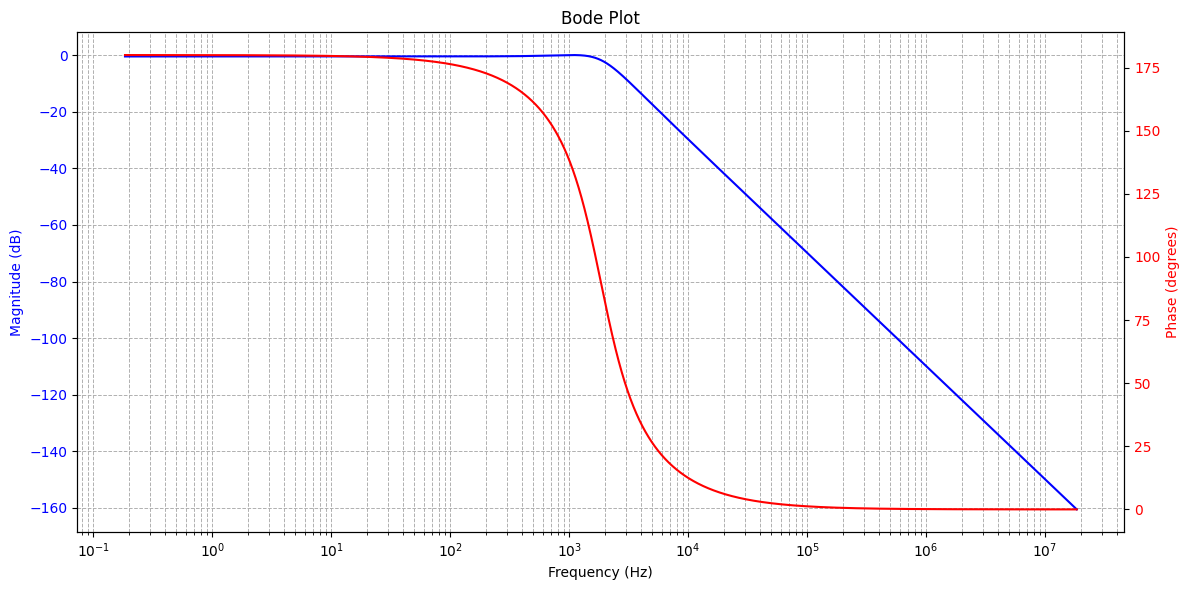


Ganancia en $\omega_{s}$ = (4500.0): -15.600[dB]

Ganancia en $\omega_{c}$ = (1500.0): -0.510[dB]


In [5]:
k_expr = -1 / R1
w0_expr = 1 / C
Q_expr = R2

values = {k: k_expr, Q: Q_expr, w0: w0_expr}

w_cheby = np.sqrt(1.5162)
fc = 1.5e3
w_c = 2 * np.pi * fc
_w0 = w_cheby * w_c

T = T.subs(values)

_Q = 0.863
_k = 0.9438

values = {C: 1 / _w0, R1: 1 / _k, R2: _Q, R3: 1}

(magnitude_db, frequencies, _) = uplt.plot_tf(T, values, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - (3 * w_c) / (2 * np.pi)))
magnitude_at_ws = magnitude_db[idx]
idx = np.argmin(np.abs(frequencies - (1 * w_c) / (2 * np.pi)))
magnitude_at_wc = magnitude_db[idx]

markdown_text = rf"""
Ganancia en $\omega_{{s}}$ = ({(3 * w_c) / (2 * np.pi)}): {magnitude_at_ws:.3f}[dB]

Ganancia en $\omega_{{c}}$ = ({(1 * w_c) / (2 * np.pi)}): {magnitude_at_wc:.3f}[dB]
"""

display(Markdown(markdown_text))

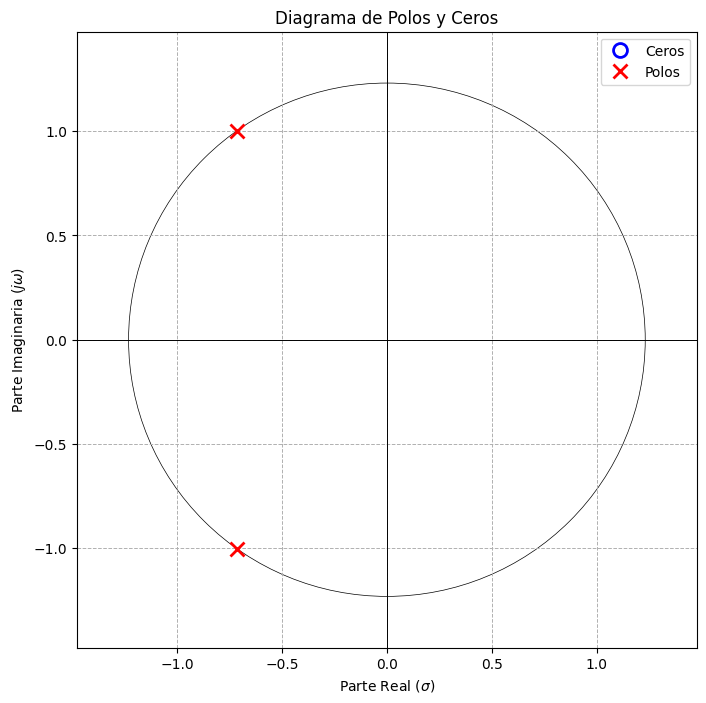

In [6]:
values = {C: 1 / (_w0/w_c), R1: 1 / _k, R2: _Q, R3: 1}
_ = uplt.plot_polos_ceros(T, _w0/w_c, values)

In [74]:
C_expr = 1 / (R3 * w0)
C_val_n = C_expr.subs({w0: 1, R3: 1})
R3_expr = 1 / (C * w0)

C_forced = 10e-9
C_forced_eng = uplt.eng_format(C_forced, "F")

# -------------------------------------------------------

R3_val = R3_expr.subs({C: C_forced, w0: _w0})
R3_eng = uplt.eng_format(float(R3_val), "\Omega")

R1_val = R3_val / _k
R1_eng = uplt.eng_format(float(R1_val), "\Omega")

R2_val = _Q * R3_val
R2_eng = uplt.eng_format(float(R2_val), "\Omega")

# -------------------------------------------------------

markdown_text = rf"""
### Valor numérico normalizado:
$$C = {C_val_n.evalf(3)}$$
### Valor numérico de $R_3$ seteando $C = {C_forced_eng}$ y $\omega_n \omega_{{\text{{cheby}}}} = {_w0:.2f}[rad/s]$:
$$R_3 = {R3_eng}$$
### Valor numérico de $R_1 = \frac{{R_3}}{{k}}$:
$$R_1 = {R1_eng}$$
### Valor numérico de $R_2 = \frac{{Q}}{{R_3}}$:
$$R_2 = {R2_eng}$$
"""
display(Markdown(markdown_text))

C_check = C_val_n / (_w0 * R3_val)
markdown_text = f"""
### Verificación de resultados ($C = \\frac{{C_{{\\text{{normalizado}}}}}}{{\\omega_{{\\text{{cheby}}}} \; \\omega_n \; \Omega_Z}}$):
$$C = {uplt.eng_format(float(C_check), "F")}$$
"""
display(Markdown(markdown_text))


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R_3$ seteando $C = 10 nF$ y $\omega_n \omega_{\text{cheby}} = 11605.11[rad/s]$:
$$R_3 = 8.62 k\Omega$$
### Valor numérico de $R_1 = \frac{R_3}{k}$:
$$R_1 = 9.13 k\Omega$$
### Valor numérico de $R_2 = \frac{Q}{R_3}$:
$$R_2 = 7.44 k\Omega$$



### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_{\text{cheby}} \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


Valores comerciales:
- $7k5$
- $9k1$
- $8k2 + 390$

### Simulación con LT Spice - fotos son de otro circuito

> TODO: falta simular, las fotos son de otro circuito

Circuito:

<div align=center>

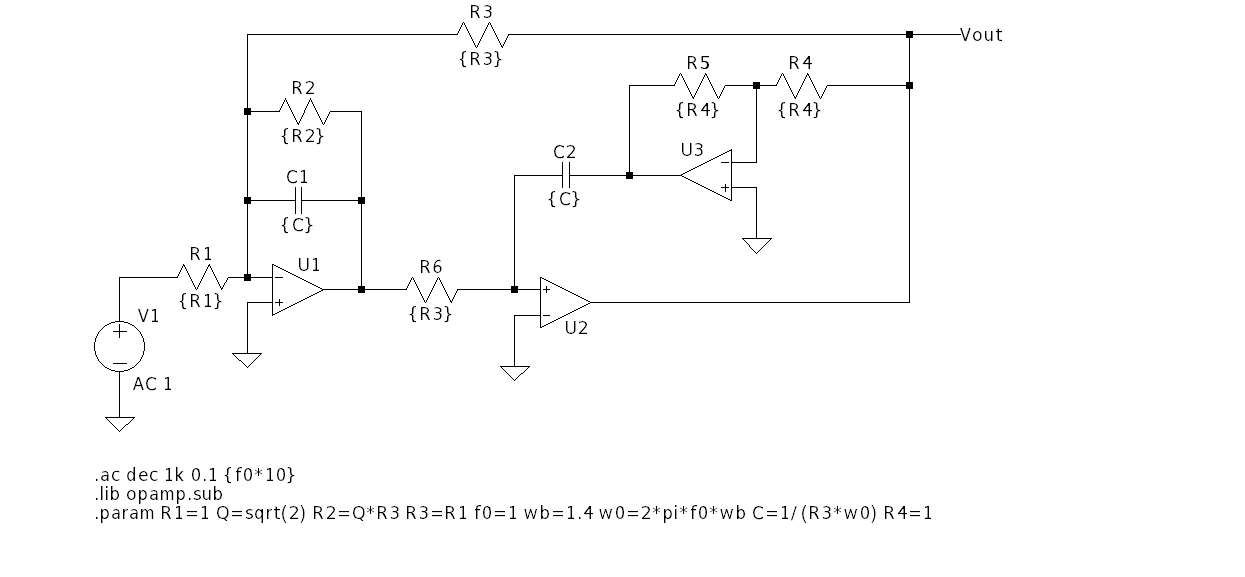

</div>

Módulo y Fase:

<div align=center>

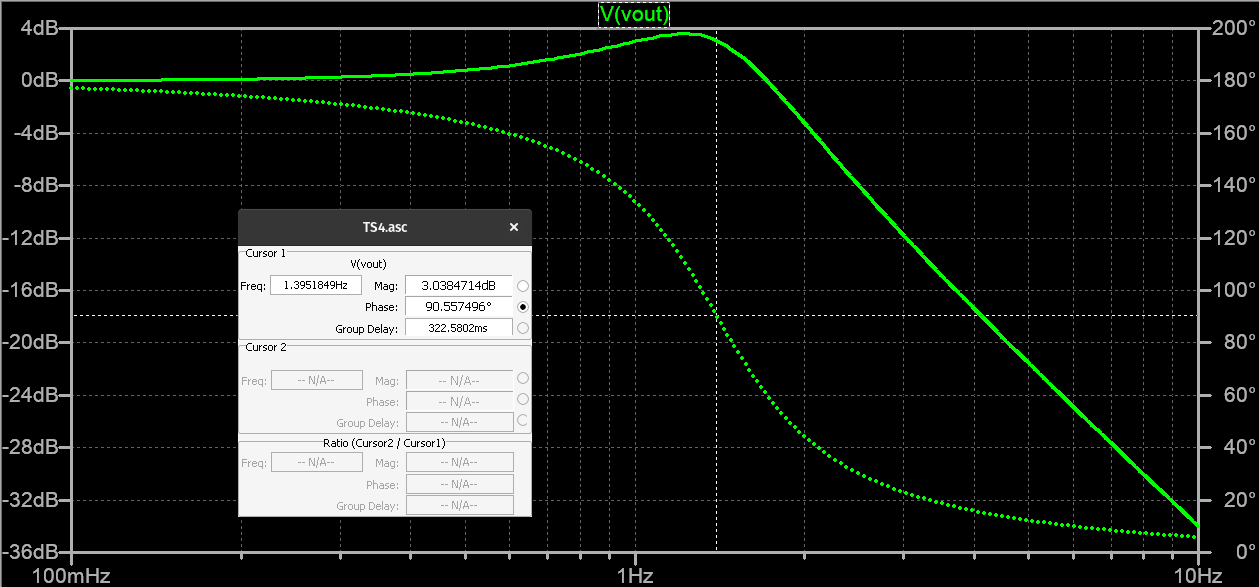

</div>

<a href="./TPL1.asc" download="TPL1.asc">Descargar TPL1.asc</a>

## Chebyshev


In [65]:
from scipy.signal import TransferFunction, cheby1

# Se puede utilizar la funcion cheby1 de scipy.signal con w = 1 para tener los coeficientes
# de la transferencia.
b, a = cheby1(N=2, rp=0.5, Wn=[1], btype="low", analog=True, output="ba")

tf = TransferFunction(b, a)
s = sp.symbols("s")
B = sum(coef * s**i for i, coef in enumerate(reversed(b)))
A = sum(coef * s**i for i, coef in enumerate(reversed(a)))

print("Transferencia Chebyshev:")
display(B / A)

Transferencia Chebyshev:


1.43138758062159/(1.0*s**2 + 1.4256245136402*s + 1.51620262694593)